# Rule-Based Fall Detector

Goal: detect falls from extracted keypoint features using simple if/else
thresholds on body angle, hip height, and velocity.

Input: keypoints CSV (extracted in Phases 1-4).
Output: per-frame fall prediction, compared against ground-truth labels.

In [16]:
import sys
sys.path.append('..') 

%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
# feature data csv
feature_df = pd.read_csv('../data/le2i_features.csv')   
print('shape:', feature_df.shape)
feature_df.head()

shape: (42066, 7)


,scene,video,true_label,frame,angle,hip_height,bbox_ratio
0,Coffee_room_01,video (1),FALL,1,NaN,NaN,NaN
1,Coffee_room_01,video (1),FALL,2,NaN,NaN,NaN
2,Coffee_room_01,video (1),FALL,3,NaN,NaN,NaN
3,Coffee_room_01,video (1),FALL,4,NaN,NaN,NaN
4,Coffee_room_01,video (1),FALL,5,NaN,NaN,NaN


In [18]:
feature_df['clip_id'] = feature_df['scene'] + '_' + feature_df['video']
feature_df['true_binary'] = (feature_df['true_label'] == 'FALL').astype(int)

print('unique clips:', feature_df['clip_id'].nunique())
print('label balance across all rows:')
print(feature_df['true_binary'].value_counts())
print('\nlabel balance across clips:')
print(feature_df.groupby('clip_id')['true_binary'].max().value_counts())

unique clips: 130
label balance across all rows:
true_binary
1    29333
0    12733
Name: count, dtype: int64

label balance across clips:
true_binary
1    99
0    31
Name: count, dtype: int64


In [19]:
# figuring out why media pipe is not able to detect a person 

feature_df['pose_detected'] = feature_df['angle'].notna() & feature_df['hip_height'].notna()

# Per-clip summary of detection rate
detection_rate = feature_df.groupby('clip_id')['pose_detected'].mean().reset_index()
detection_rate.columns = ['clip_id', 'detection_rate']

print(detection_rate.describe())
print('\nclips with <50% detection:')
# Home_02 has 19 clips where detection rate it quite low compared to Home_01 - 9 clips and Coffee_room_01 - 2 clips
print(detection_rate[detection_rate['detection_rate'] < 0.5])

       detection_rate
count      130.000000
mean         0.734640
std          0.258140
min          0.092949
25%          0.524306
50%          0.807122
75%          0.982502
max          1.000000

clips with <50% detection:
                       clip_id  detection_rate
5    Coffee_room_01_video (14)        0.397727
7    Coffee_room_01_video (16)        0.384181
71          Home_01_video (10)        0.451923
72          Home_01_video (11)        0.391026
73          Home_01_video (12)        0.472222
74          Home_01_video (13)        0.354167
76          Home_01_video (15)        0.453782
85          Home_01_video (23)        0.387500
95           Home_01_video (5)        0.265625
96           Home_01_video (6)        0.489583
99           Home_01_video (9)        0.434524
102         Home_02_video (33)        0.322917
103         Home_02_video (34)        0.412500
105         Home_02_video (36)        0.166667
108         Home_02_video (39)        0.494792
109         Home_02_vi

In [20]:
# rules are spine angle > 45, hip height > 0.5 (lower half of frame), and both spine and hip rules are true for at least 3 consecutive frames
work = feature_df[['clip_id', 'frame', 'angle', 'hip_height', 'true_binary']].copy()

work['pred_frame'] = (
    (work['angle'] >= 45) &
    (work['hip_height'] > 0.5)
).astype(int)

work = work.sort_values(['clip_id', 'frame']).reset_index(drop=True)

# 3 consecutive frames requirement
work['pred_consecutive'] = (
    work.groupby('clip_id')['pred_frame']
        .rolling(window=3, min_periods=3)
        .min()
        .reset_index(level=0, drop=True)
)

print('flagged frames (single rule) :', int(work['pred_frame'].sum()))
print('flagged frames (3 consecutive):', int(work['pred_consecutive'].sum()))
work.head()

flagged frames (single rule) : 6665
flagged frames (3 consecutive): 6154


,clip_id,frame,angle,hip_height,true_binary,pred_frame,pred_consecutive
0,Coffee_room_01_video (1),1,NaN,NaN,1,0,NaN
1,Coffee_room_01_video (1),2,NaN,NaN,1,0,NaN
2,Coffee_room_01_video (1),3,NaN,NaN,1,0,0.0
3,Coffee_room_01_video (1),4,NaN,NaN,1,0,0.0
4,Coffee_room_01_video (1),5,NaN,NaN,1,0,0.0


In [21]:
# evaluations for rule based
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

clip_results = work.groupby('clip_id').agg(
    pred_clip=('pred_consecutive', 'max'),
    true_clip=('true_binary', 'max'),
).reset_index()

# pred_clip may be NaN for clips shorter than 3 frames. Fill with 0.
clip_results['pred_clip'] = clip_results['pred_clip'].fillna(0).astype(int)

y_true = clip_results['true_clip']
y_pred = clip_results['pred_clip']

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

print('confusion matrix:')
print('              pred_nofall  pred_fall')
print(f'true_nofall   {tn:>11}  {fp:>9}')
print(f'true_fall     {fn:>11}  {tp:>9}')
print()
print(f'accuracy : {accuracy_score(y_true, y_pred):.3f}')
print(f'precision: {precision_score(y_true, y_pred, zero_division=0):.3f}')
print(f'recall   : {recall_score(y_true, y_pred, zero_division=0):.3f}')
print(f'f1       : {f1_score(y_true, y_pred, zero_division=0):.3f}')

confusion matrix:
              pred_nofall  pred_fall
true_nofall            29          2
true_fall              12         87

accuracy : 0.892
precision: 0.978
recall   : 0.879
f1       : 0.926


Trying new approach: having a 3 step rule
1. Descent event - downwards hip velocity exceeding threshold
2. Fall posture - within N frames of descent event, spine angle and bounding box width-height ratio thresholds are triggered
3. Persistence - fallen posture must hold for N frames

In [22]:
FPS = 25

# Make sure data is sorted before differencing
feature_df = feature_df.sort_values(['clip_id', 'frame']).reset_index(drop=True)

# Per-frame change in hip height, computed within each clip, scaled to per-second
feature_df['hip_velocity'] = (
    feature_df.groupby('clip_id')['hip_height'].diff() * FPS
)

print('hip_velocity added. Columns now:', feature_df.columns.tolist())

hip_velocity added. Columns now: ['scene', 'video', 'true_label', 'frame', 'angle', 'hip_height', 'bbox_ratio', 'clip_id', 'true_binary', 'pose_detected', 'hip_velocity']


In [23]:
# Define clip-level ground truth and the fall-detection functions

clip_truth = (
    feature_df.groupby('clip_id')['true_binary']
    .max()
    .reset_index()
    .rename(columns={'true_binary': 'true_clip'})
)


def detect_fall_in_clip_or(group, V, N, P, max_gap,
                           angle_thresh, bbox_thresh):
    g = group.sort_values('frame').reset_index(drop=True)

    state = 0
    wait_counter = 0
    persist_counter = 0
    gap_counter = 0

    for _, row in g.iterrows():
        vel   = row['hip_velocity']
        angle = row['angle']
        bbox  = row['bbox_ratio']

        posture = ((pd.notna(angle) and angle >= angle_thresh) or
                   (pd.notna(bbox)  and bbox  > bbox_thresh))
        descent = pd.notna(vel) and vel > V

        if state == 0:
            if descent:
                state = 1
                wait_counter = 0

        elif state == 1:
            wait_counter += 1
            if posture:
                state = 2
                persist_counter = 1
                gap_counter = 0
            elif wait_counter >= N:
                state = 0

        elif state == 2:
            if posture:
                persist_counter += 1
                gap_counter = 0
                if persist_counter >= P:
                    return 1
            else:
                gap_counter += 1
                if gap_counter > max_gap:
                    state = 0
                    persist_counter = 0
                    gap_counter = 0

    return 0


def detect_fall_in_clip_with_trace(group, V, N, P,
                                   max_gap=12,
                                   angle_thresh=45,
                                   bbox_thresh=0.85):
    g = group.sort_values('frame').reset_index(drop=True)

    descent_count = 0
    posture_count = 0
    max_persistence = 0

    state = 0
    wait_counter = 0
    persist_counter = 0
    gap_counter = 0

    for _, row in g.iterrows():
        vel   = row['hip_velocity']
        angle = row['angle']
        bbox  = row['bbox_ratio']

        posture = ((pd.notna(angle) and angle >= angle_thresh) or
                   (pd.notna(bbox)  and bbox  > bbox_thresh))
        descent = pd.notna(vel) and vel > V

        if descent:
            descent_count += 1
        if posture:
            posture_count += 1

        if state == 0:
            if descent:
                state, wait_counter = 1, 0
        elif state == 1:
            wait_counter += 1
            if posture:
                state, persist_counter, gap_counter = 2, 1, 0
                max_persistence = max(max_persistence, persist_counter)
            elif wait_counter >= N:
                state = 0
        elif state == 2:
            if posture:
                persist_counter += 1
                gap_counter = 0
                max_persistence = max(max_persistence, persist_counter)
            else:
                gap_counter += 1
                if gap_counter > max_gap:
                    state = 0
                    persist_counter = 0
                    gap_counter = 0

    return {
        'descent_count': descent_count,
        'posture_count': posture_count,
        'max_persistence': max_persistence,
    }

In [24]:
# Final tuned rule
FINAL_V = 0.215      # Hip velocity threshold
FINAL_N = 30         # Number of frames after descent event to wait for posture confirmation
FINAL_P = 2          # Number of frames posture must hold true to confirm fall
FINAL_MAX_GAP = 12    # Number of null frames allowed within posture sequence before streak rests
FINAL_ANGLE = 45     # Spine angle (degrees from vertical)
FINAL_BBOX = 0.85     # bounding box width-to-height ratio 

# Run the final rules
final_preds = []
for clip_id, group in feature_df.groupby('clip_id'):
    pred = detect_fall_in_clip_or(
        group, 
        V=FINAL_V, 
        N=FINAL_N, 
        P=FINAL_P, 
        max_gap=FINAL_MAX_GAP,
        angle_thresh=FINAL_ANGLE, 
        bbox_thresh=FINAL_BBOX
    )
    final_preds.append({'clip_id': clip_id, 'pred_clip': pred})

final_results = pd.DataFrame(final_preds).merge(clip_truth, on='clip_id')

# Print final metrics
y_true = final_results['true_clip']
y_pred = final_results['pred_clip']
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

print('FINAL TUNED RULE: OR posture, P=2')
print('---------------------------------')
print(f'  TN={tn}  FP={fp}  FN={fn}  TP={tp}')
print(f'  accuracy : {accuracy_score(y_true, y_pred):.3f}')
print(f'  precision: {precision_score(y_true, y_pred, zero_division=0):.3f}')
print(f'  recall   : {recall_score(y_true, y_pred, zero_division=0):.3f}')
print(f'  f1       : {f1_score(y_true, y_pred, zero_division=0):.3f}')

FINAL TUNED RULE: OR posture, P=2
---------------------------------
  TN=23  FP=8  FN=6  TP=93
  accuracy : 0.892
  precision: 0.921
  recall   : 0.939
  f1       : 0.930


Finite state machine tends to perform a lot better in the context of a fall detector. The F1 scores differ by less than 
1%. Although the number of false negatives have halfed from 12->6 using the state machine. This is crucial because a fall going 
undetected is a lot worse than having a false alarm as in this case you would rather be safe then sorry. 

Let's try diving deeper into the incorrect predictions (false positives and false negatives) to better understand why there are incorrectly being predicted

In [25]:
detection_rate = feature_df.groupby('clip_id').apply(
    lambda g: g['angle'].notna().mean()
).reset_index()
detection_rate.columns = ['clip_id', 'detection_rate']

trace_results = []
for clip_id, group in feature_df.groupby('clip_id'):
    result = detect_fall_in_clip_with_trace(
        group, V=FINAL_V, N=FINAL_N, P=FINAL_P
    )
    result['clip_id'] = clip_id
    trace_results.append(result)
trace_df = pd.DataFrame(trace_results)

analysis_df = (
    final_results
    .merge(detection_rate, on='clip_id')
    .merge(trace_df[['clip_id', 'descent_count', 'posture_count', 'max_persistence']], 
           on='clip_id')
)

fns = analysis_df[(analysis_df['true_clip'] == 1) & (analysis_df['pred_clip'] == 0)]
fps = analysis_df[(analysis_df['true_clip'] == 0) & (analysis_df['pred_clip'] == 1)]

print(f'False negatives: {len(fns)}')
print(f'False positives: {len(fps)}')

/var/folders/v4/l4010phn7tqggs_lkdm53t9h0000gn/T/ipykernel_59595/1966298645.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  detection_rate = feature_df.groupby('clip_id').apply(


False negatives: 6
False positives: 8


For false negatives, most of these occur when fall is in line with camera. Since the person falls and their body doesn't exactly spread out in the x direction, I believe that is why these falls are not being detected. 

In [26]:
# For each FN, check max angle, max bbox, and max velocity in that clip
fn_details = []
for cid in fns['clip_id']:
    clip = feature_df[feature_df['clip_id'] == cid]
    fn_details.append({
        'clip_id': cid,
        'detection_rate': fns[fns['clip_id'] == cid]['detection_rate'].iloc[0],
        'max_angle': clip['angle'].max(),
        'max_bbox': clip['bbox_ratio'].max(),
        'max_velocity': clip['hip_velocity'].max(),
        'frames_angle_ok': (clip['angle'] >= 45).sum(),
        'frames_bbox_ok': (clip['bbox_ratio'] > 1.0).sum(),
        'frames_either': ((clip['angle'] >= 45) | (clip['bbox_ratio'] > 1.0)).sum(),
    })

fn_details_df = pd.DataFrame(fn_details).sort_values('detection_rate', ascending=False)
print('All false negatives, sorted by detection rate:')
print(fn_details_df.to_string(index=False))

All false negatives, sorted by detection rate:
                  clip_id  detection_rate  max_angle  max_bbox  max_velocity  frames_angle_ok  frames_bbox_ok  frames_either
Coffee_room_01_video (15)        0.907143    26.8752    0.5920        0.8750                0               0              0
Coffee_room_01_video (30)        0.737931    20.6077    0.9183        0.5325                0               0              0
       Home_02_video (34)        0.412500    26.2909    0.7475        0.9100                0               0              0
Coffee_room_01_video (14)        0.397727    23.6219    0.5697        0.2900                0               0              0
       Home_02_video (33)        0.322917    38.3947    1.1574        0.7625                0               1              1
       Home_02_video (36)        0.166667    41.7151    0.6746        1.1550                0               0              0


The false postives are caused by movements like sitting down suddenly.

In [27]:
# For each FP, check max angle, max bbox, and max velocity in that clip
fp_details = []
for cid in fps['clip_id']:
    clip = feature_df[feature_df['clip_id'] == cid]
    fp_details.append({
        'clip_id': cid,
        'detection_rate': fps[fps['clip_id'] == cid]['detection_rate'].iloc[0],
        'max_angle': clip['angle'].max(),
        'max_bbox': clip['bbox_ratio'].max(),
        'max_velocity': clip['hip_velocity'].max(),
        'frames_angle_ok': (clip['angle'] >= 45).sum(),
        'frames_bbox_ok': (clip['bbox_ratio'] > 1.0).sum(),
        'frames_either': ((clip['angle'] >= 45) | (clip['bbox_ratio'] > 1.0)).sum(),
    })

fp_details_df = pd.DataFrame(fp_details).sort_values('detection_rate', ascending=False)
print('All false positives, sorted by detection rate:')
print(fp_details_df.to_string(index=False))

All false positives, sorted by detection rate:
                  clip_id  detection_rate  max_angle  max_bbox  max_velocity  frames_angle_ok  frames_bbox_ok  frames_either
Coffee_room_02_video (61)        0.966514    61.9177    1.1174        0.9825               15              18             33
Coffee_room_02_video (68)        0.848787   176.4171    0.7550        0.8950                4               0              4
Coffee_room_02_video (70)        0.678188   178.3977    0.7113        0.9400               12               0             12
       Home_02_video (53)        0.509259   131.0662    0.8643        0.6225                7               0              7
       Home_02_video (39)        0.494792    91.3087    0.8967        1.3525                5               0              5
       Home_02_video (44)        0.458599   177.9439    0.7580        0.9225               16               0             16
       Home_02_video (48)        0.429167    64.8350    0.9694        0.3000  

Clip: Coffee_room_01_video (30)
Total frames: 145
Frames with detected pose: 107

Frames where descent fires (vel > 0.215): [5, 7, 9, 76, 81, 82, 83, 84, 85, 89, 105]
Frames where posture fires (angle OR bbox): [93]


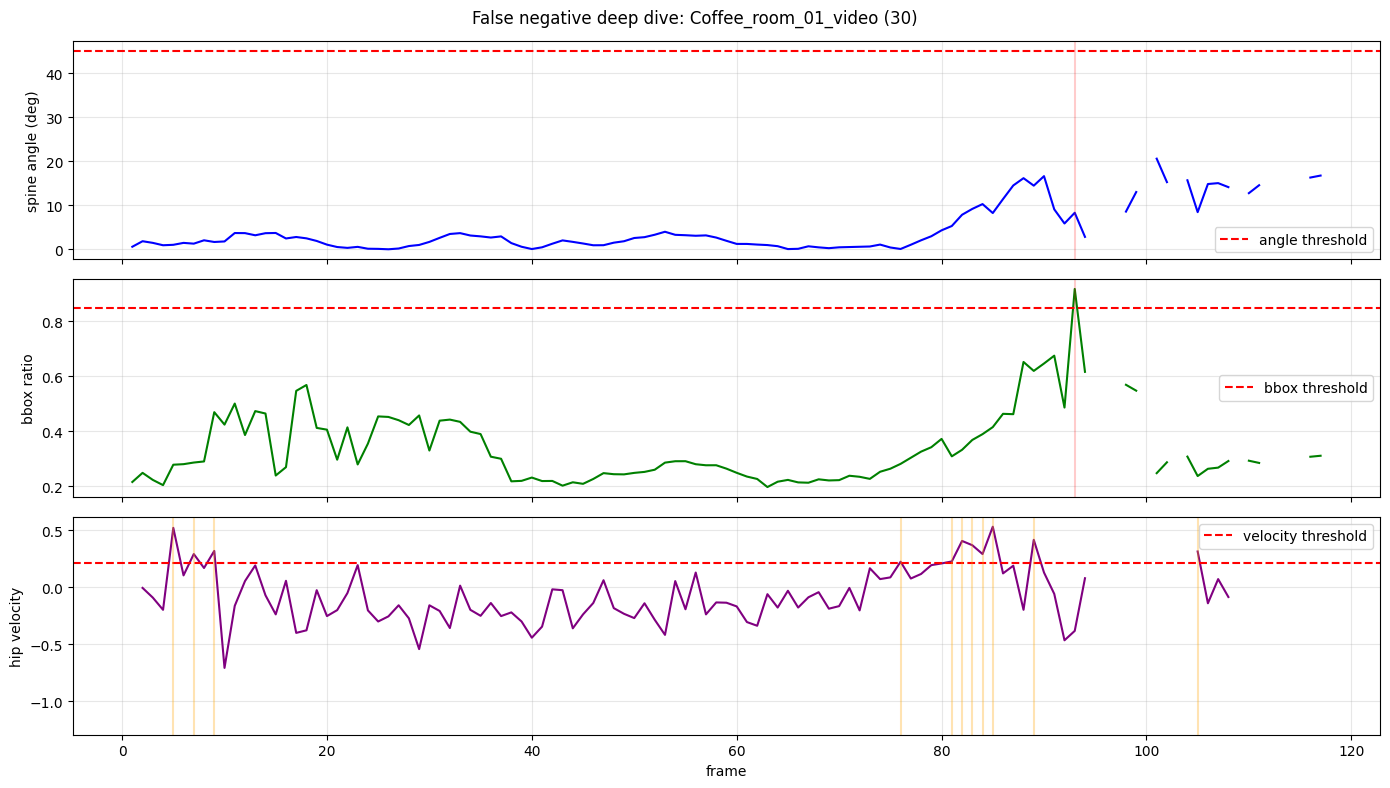

In [28]:
# Deep Dive into a specific video clip as it shows spine angle, bounding box ratio, and downwards hip velocity
clip_id_to_inspect = 'Coffee_room_01_video (30)'
clip = feature_df[feature_df['clip_id'] == clip_id_to_inspect].copy()

print(f'Clip: {clip_id_to_inspect}')
print(f'Total frames: {len(clip)}')
print(f'Frames with detected pose: {clip["angle"].notna().sum()}')
print()

# Find frames where each condition fires
descent_frames = clip[clip['hip_velocity'] > 0.215]['frame'].tolist()
posture_frames = clip[(clip['angle'] >= 45) | (clip['bbox_ratio'] > 0.85)]['frame'].tolist()

print(f'Frames where descent fires (vel > 0.215): {descent_frames}')
print(f'Frames where posture fires (angle OR bbox): {posture_frames}')

# Plot all signals over time with markers
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].plot(clip['frame'], clip['angle'], color='blue')
axes[0].axhline(45, color='red', linestyle='--', label='angle threshold')
axes[0].set_ylabel('spine angle (deg)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(clip['frame'], clip['bbox_ratio'], color='green')
axes[1].axhline(0.85, color='red', linestyle='--', label='bbox threshold')
axes[1].set_ylabel('bbox ratio')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(clip['frame'], clip['hip_velocity'], color='purple')
axes[2].axhline(0.215, color='red', linestyle='--', label='velocity threshold')
axes[2].set_ylabel('hip velocity')
axes[2].set_xlabel('frame')
axes[2].legend()
axes[2].grid(alpha=0.3)

# Mark descent and posture frames on the velocity plot
for f in descent_frames:
    axes[2].axvline(f, color='orange', alpha=0.3)
for f in posture_frames:
    axes[0].axvline(f, color='red', alpha=0.2)
    axes[1].axvline(f, color='red', alpha=0.2)

plt.suptitle(f'False negative deep dive: {clip_id_to_inspect}')
plt.tight_layout()
plt.show()

Deep Dive into why media pipe is not able to find and extract key points.

In [29]:
# 5 clips with the most missing MediaPipe detections
worst_detection = (
    feature_df.groupby('clip_id')
    .agg(
        total_frames=('frame', 'count'),
        frames_with_pose=('pose_detected', 'sum'),
        detection_rate=('pose_detected', 'mean'),
    )
    .reset_index()
    .sort_values('detection_rate', ascending=True)
    .head(10)
)

worst_detection['frames_missing'] = (
    worst_detection['total_frames'] - worst_detection['frames_with_pose']
)

print('5 clips with the most missing MediaPipe detections:')
print(worst_detection.to_string(index=False))

5 clips with the most missing MediaPipe detections:
           clip_id  total_frames  frames_with_pose  detection_rate  frames_missing
Home_02_video (60)           312                29        0.092949             283
Home_02_video (40)           240                39        0.162500             201
Home_02_video (36)           192                32        0.166667             160
Home_02_video (58)           336                70        0.208333             266
Home_02_video (49)           312                71        0.227564             241
Home_02_video (50)           312                71        0.227564             241
Home_02_video (59)           216                55        0.254630             161
 Home_01_video (5)           192                51        0.265625             141
Home_02_video (57)           240                69        0.287500             171
Home_02_video (41)           240                70        0.291667             170


In [30]:
# runs media pipe on selected video - used to understand why mediapipe is not able to identify the person in the frame
import cv2
import mediapipe as mp
import numpy as np

# path to video
VIDEO_PATH = '../data/Le2i/Home_02/Home_02/Videos/video (36).avi'

mp_pose = mp.solutions.pose
mp_draw = mp.solutions.drawing_utils
pose = mp_pose.Pose(
    static_image_mode=False,
    model_complexity=1,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5,
)

cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise RuntimeError(f'Could not open {VIDEO_PATH}')

frame_idx = 0
detected_count = 0

while True:
    ok, frame = cap.read()
    if not ok:
        break

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = pose.process(rgb)

    h, w, _ = frame.shape

    if results.pose_landmarks:
        detected_count += 1

        # Draw skeleton
        mp_draw.draw_landmarks(
            frame,
            results.pose_landmarks,
            mp_pose.POSE_CONNECTIONS,
        )

        # Compute bounding box from all visible landmarks
        xs, ys = [], []
        for lm in results.pose_landmarks.landmark:
            if lm.visibility > 0.5:
                xs.append(lm.x * w)
                ys.append(lm.y * h)

        if xs and ys:
            x1, y1 = int(min(xs)), int(min(ys))
            x2, y2 = int(max(xs)), int(max(ys))
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)

            bbox_w = x2 - x1
            bbox_h = y2 - y1
            ratio = bbox_w / bbox_h if bbox_h > 0 else 0
            cv2.putText(frame, f'bbox ratio: {ratio:.2f}',
                        (10, 60), cv2.FONT_HERSHEY_SIMPLEX,
                        0.7, (0, 255, 0), 2)
        status = 'POSE DETECTED'
        color = (0, 255, 0)
    else:
        status = 'NO POSE'
        color = (0, 0, 255)

    # Overlay frame number and detection status
    cv2.putText(frame, f'frame {frame_idx}  {status}',
                (10, 30), cv2.FONT_HERSHEY_SIMPLEX,
                0.7, color, 2)

    cv2.imshow('MediaPipe', frame)

    # Press q to quit, space to pause
    key = cv2.waitKey(30) & 0xFF
    if key == ord('q'):
        break
    if key == ord(' '):
        cv2.waitKey(0)  
        
    frame_idx += 1

cap.release()
cv2.destroyAllWindows()
pose.close()

print(f'Detected pose in {detected_count}/{frame_idx} frames '
      f'({detected_count / max(frame_idx, 1):.1%})')

I0000 00:00:1776916842.515110 3702570 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2
W0000 00:00:1776916842.603379 3703246 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776916842.614238 3703251 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
/Users/aryanbaldua/Library/Python/3.11/lib/python/site-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Detected pose in 53/192 frames (27.6%)
